In [60]:
import sys
sys.path.append("..")
%run "../moduli.py"

Funzione Teorica
$$
A(f)=
\frac{
\mathrm{area}\cdot 2\delta \cdot \left(\frac{R}{R+R_L}\right)\cdot \omega
}{
\sqrt{
\omega^4
-
2\omega^2\left(\Omega^2-2\delta^2\right)
+
\Omega^4
}
}
+
y_{\mathrm{off}}
$$

$$
\omega = 2\pi(f+x_{\mathrm{off}})
$$

In [61]:
def modello(par, f):  # capi di C
    Omega, Q, area, x_off, y_off = par
    omega = 2 * np.pi * (f + x_off)
    #omega = f + x_off
    return area / np.sqrt(
        (1 - (omega**2 / Omega**2))**2 +
        (1 / Q**2) * (omega**2 / Omega**2)
    ) + y_off

param_labels = ["\\omega_0", "Q", "A", "f_{off}", "A_{off}"]

beta0 = [2*np.pi*70000, 6, 1, 1, 1]

print(beta0[0])

439822.971502571


In [62]:
def modello(par, f):  # capi di R (destra)
    Omega, Q, area, delta, x_off, y_off = par
    R = 9.94
    RL = 11.46
    omega = 2 * np.pi * (f + x_off)
    #omega = f + x_off
    return (area * 2 * delta * (R / (R + RL)) * omega) / np.sqrt(
        1 + Q**2 * (Omega/omega - omega/Omega)**2
    ) + y_off

param_labels = ["\\omega_0", "Q", "A", "\\delta", "f_{off}", "A_{off}"]

beta0 = [2*np.pi*70000, 6, 1, 9.94 / (2 * 0.491e-3), 1, 1]

print(beta0)

[439822.971502571, 6, 1, 10122.199592668023, 1, 1]


In [63]:
def modello(par, f):  # capi di R (sinistra)
    Omega, area, delta, x_off, y_off = par
    R = 9.94
    RL = 11.46
    omega = 2 * np.pi * (f + x_off)
    #omega = f + x_off
    return (area * 2 * delta * (R / (R + RL)) * omega) / np.sqrt(
        omega**4 - 2*omega**2 * (Omega**2-2*delta**2) + Omega**4
    ) + y_off

param_labels = ["\\omega_0", "A", "\\delta", "f_{off}", "A_{off}"]

beta0 = [2*np.pi*70000, 1, 9.94 / (2 * 0.491e-3), 1, 1]

print(beta0)

[439822.971502571, 1, 10122.199592668023, 1, 1]


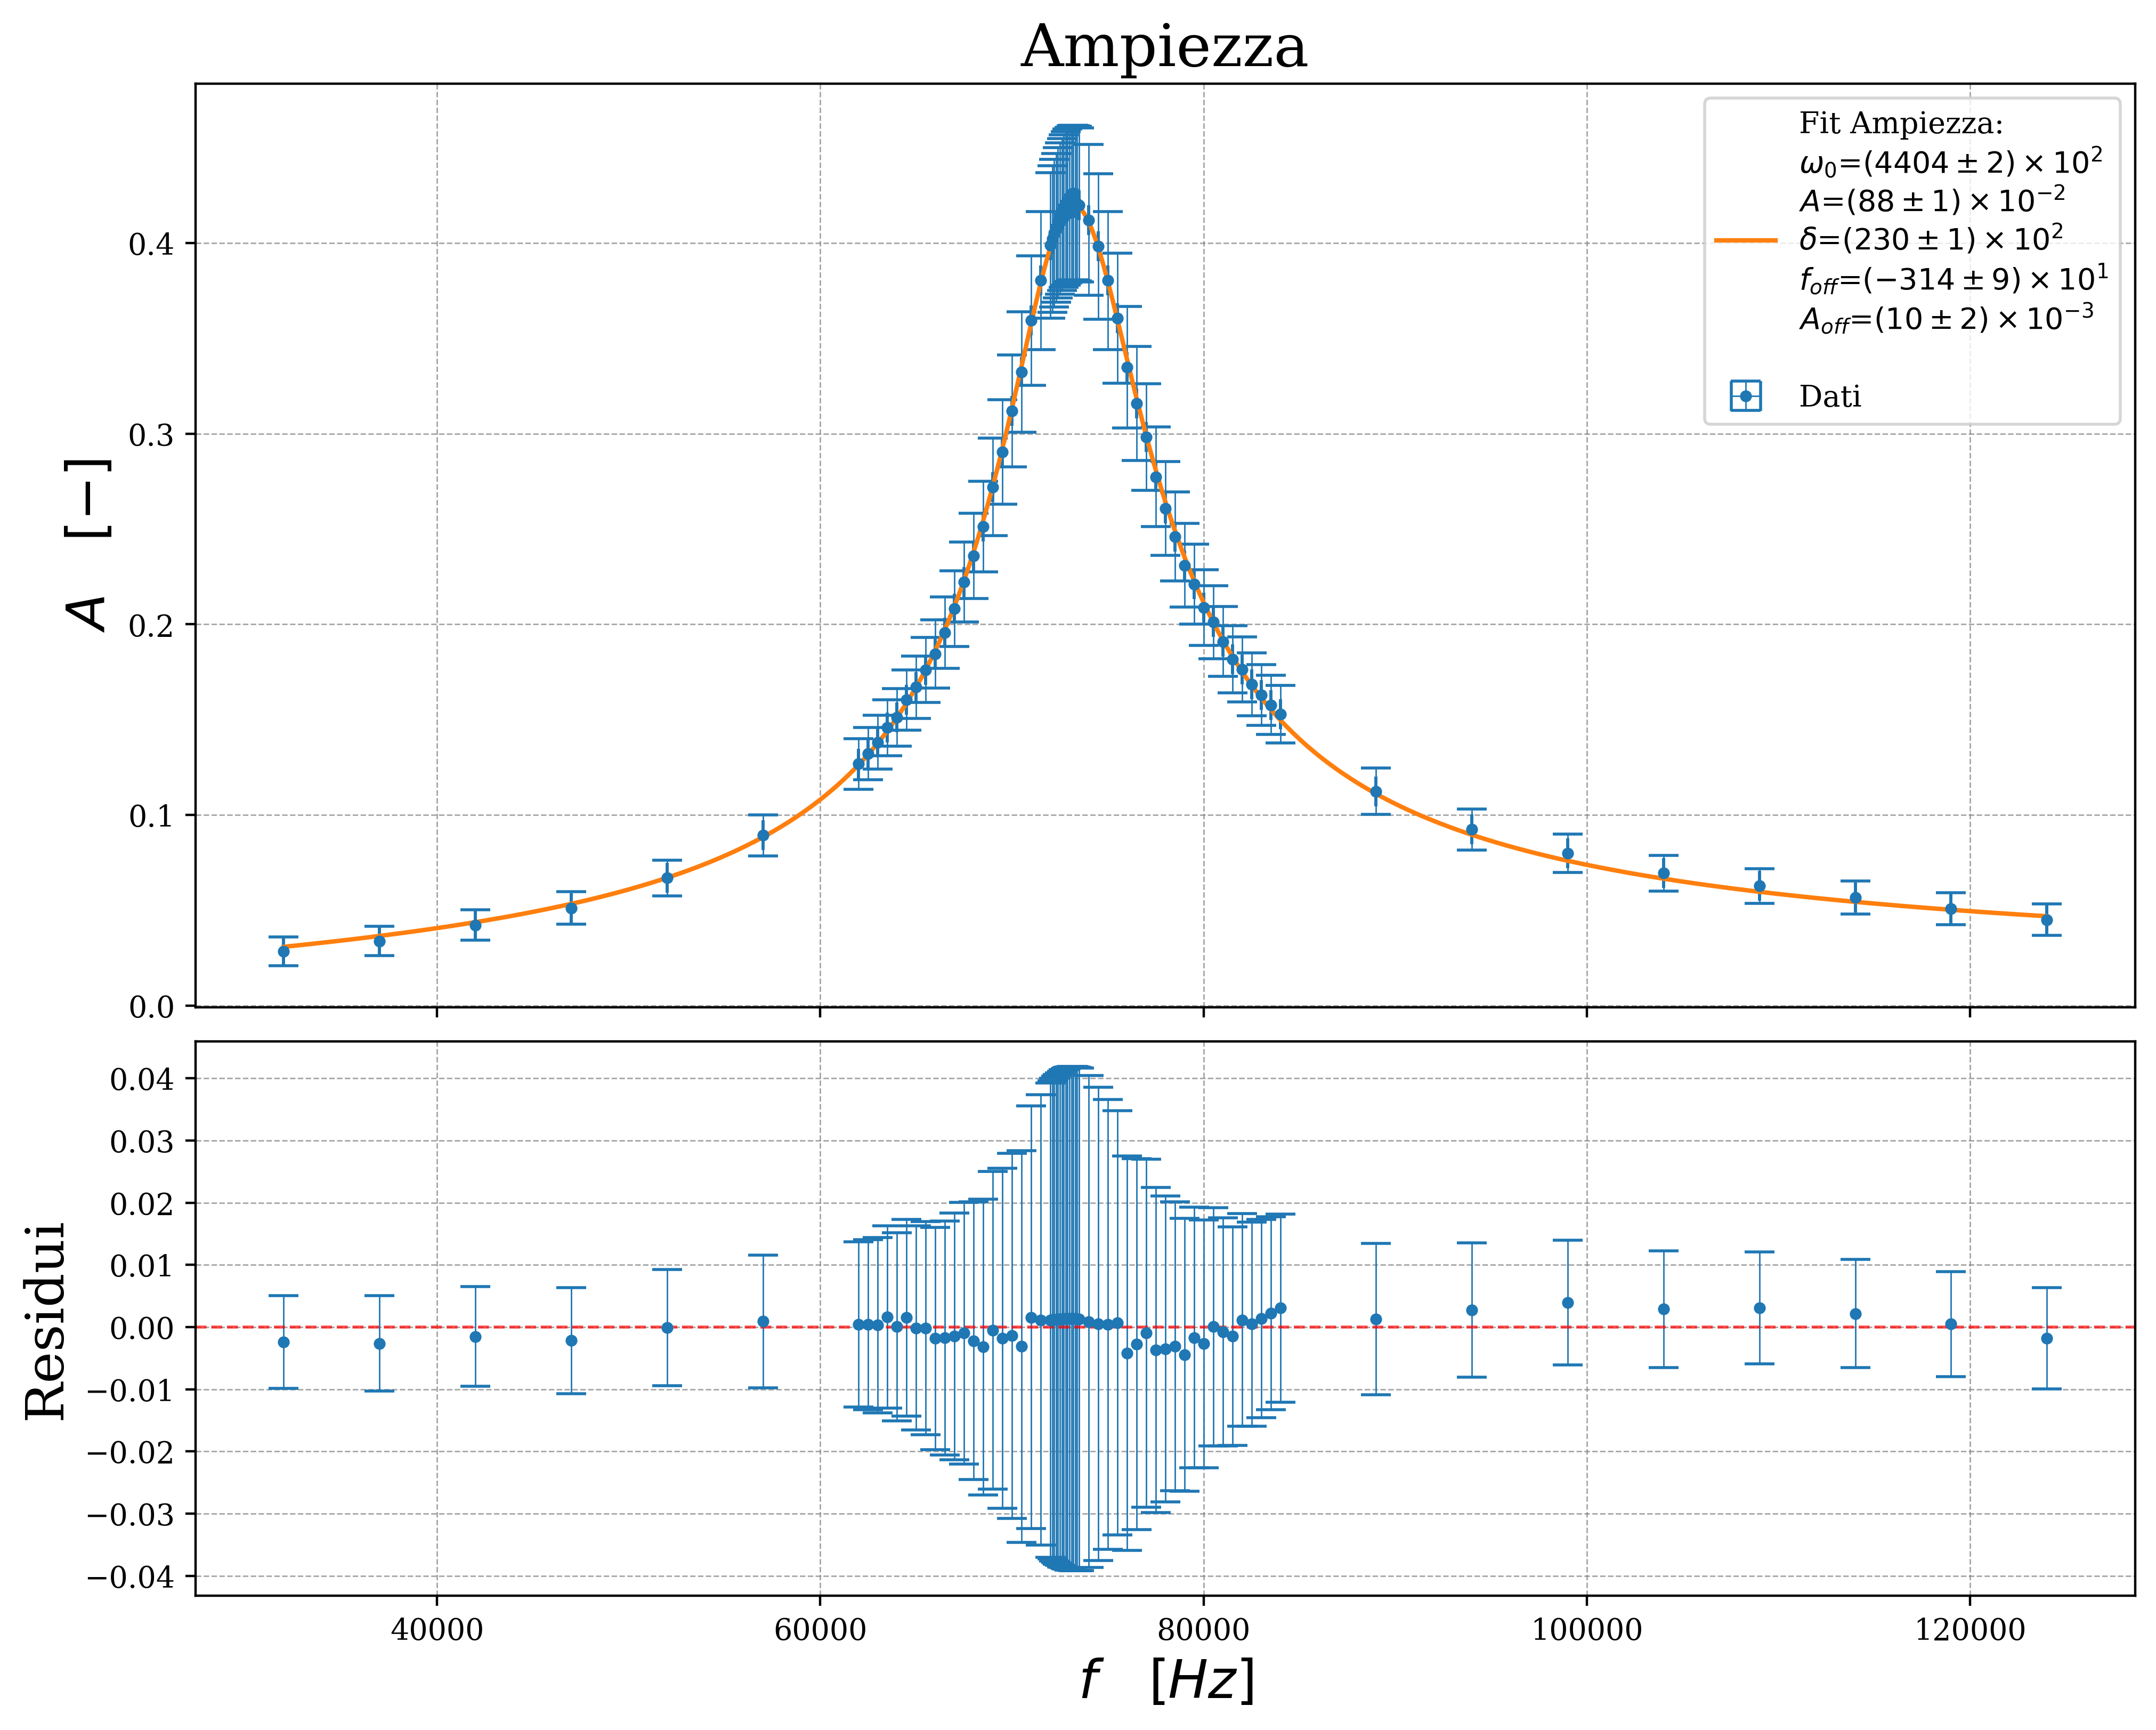

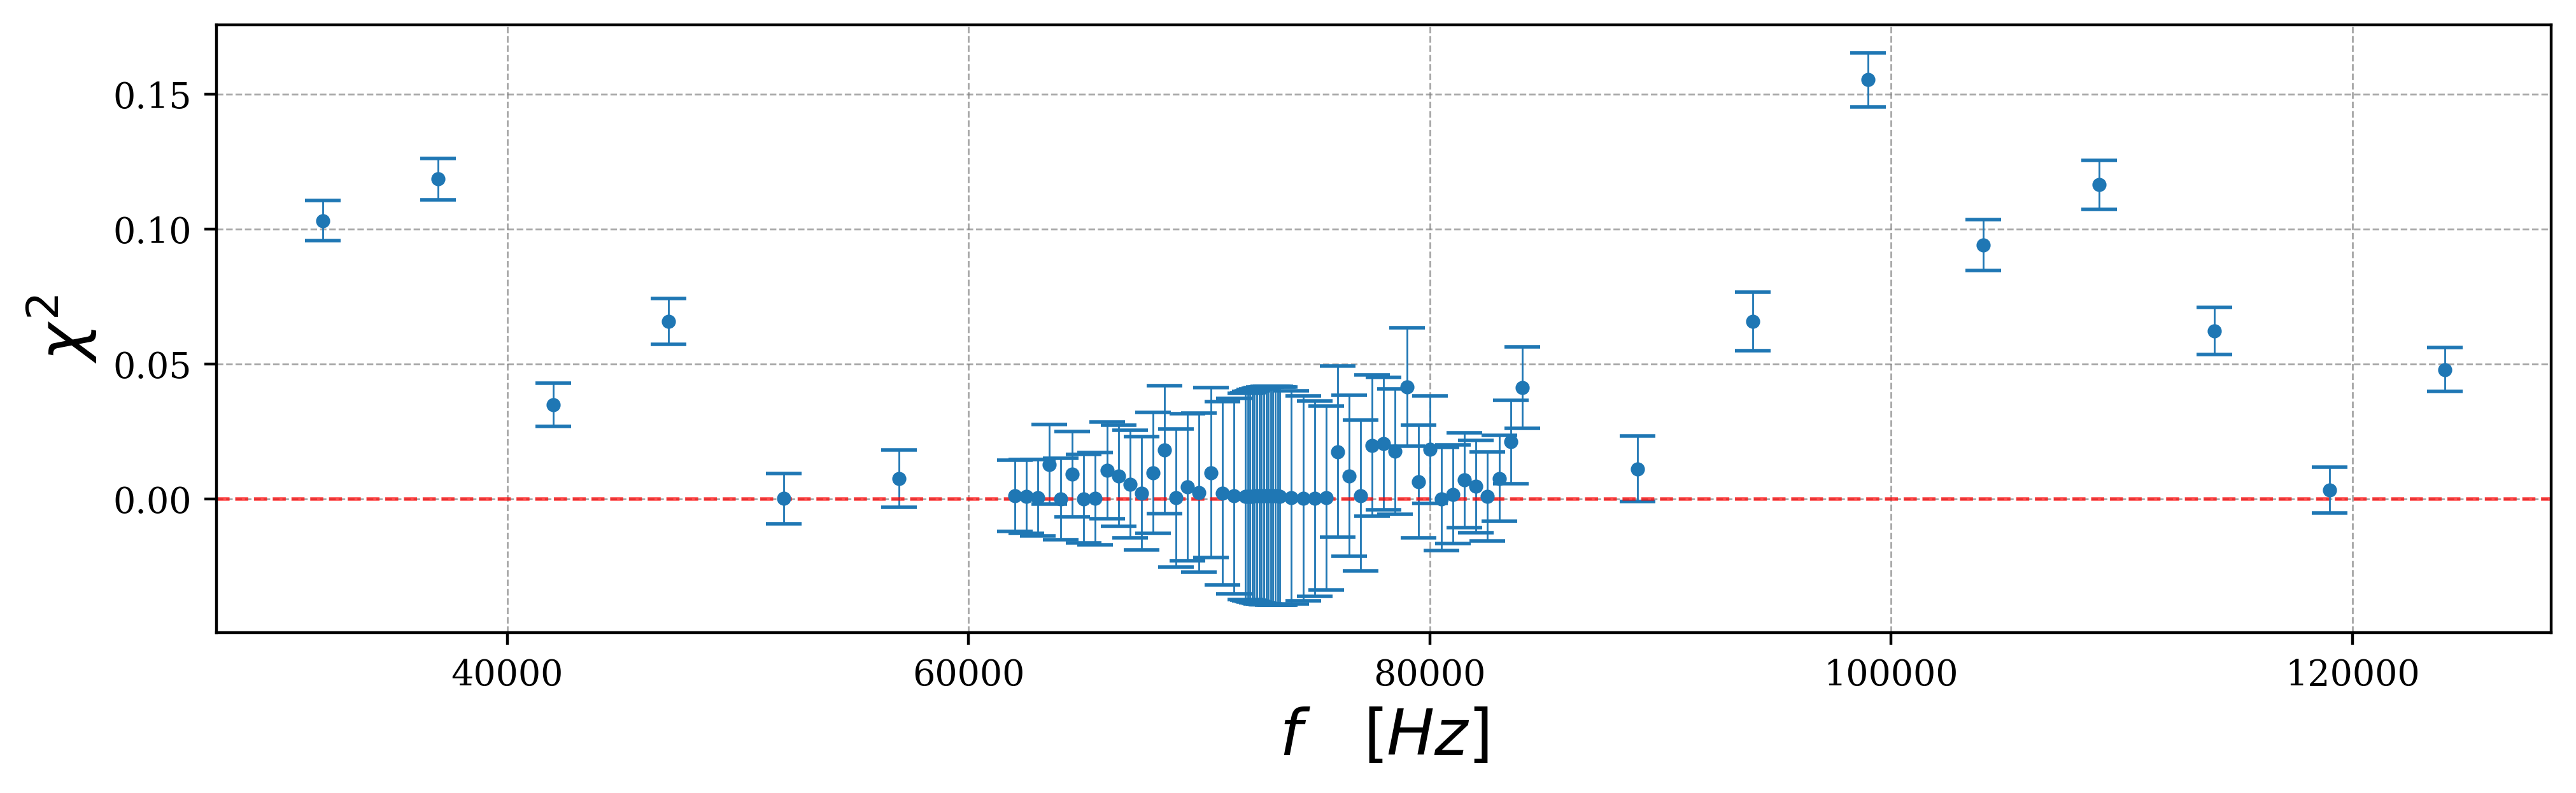

In [64]:
analisi = analizza("ampiezza", modello, param_labels, beta0, legenda_fontsize = 10)

In [65]:
print(analisi)

Parametri regressione :
440430.37444729067 ± 197.1554131226507
0.8823042430285689 ± 0.011360925497803749
22957.146555234904 ± 147.7753390305933
-3140.9285232966067 ± 88.09594573681821
0.009817598167933412 ± 0.0019649294551075053

Somma residui :
-0.0020
Somma chi quadri e chi ridotto :
1.2379
0.0188



In [66]:
par = analisi.anal[0]
spar = analisi.anal[1]

parametri_profilazione = [[par[0], par[1], par[2]], [spar[0], spar[1], spar[2]]]
parametri_offset = [par[3], par[4]]
parametri = [parametri_profilazione, parametri_offset]
let.esporta_pickle(parametri, "ampiezza.pkl")